# Telco Customer Churn — Analysis and Model Development

**Business problem.** The retention team can only call a limited number of customers per month. They need a ranked list of who is about to leave, and they need to understand *why* so the offer can be matched to the reason.

**Target.** `Churn` (Yes/No). **Model family.** Decision Tree — chosen partly because the retention team can read the split rules directly, which matters more here than squeezing out the last point of AUC.

This notebook imports from `src/`, the same modules the API uses. Nothing is reimplemented here, so anything validated in this notebook is what runs in production.

Run order: top to bottom. Set the working directory to the project root first.

In [1]:
import sys
from pathlib import Path

# Make the project root importable when the notebook is opened from notebook/.
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import config, data
from src.features import ChurnFeatureBuilder
from src.pipeline import build_pipeline, feature_names

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
np.random.seed(config.RANDOM_STATE)

## 1. Data understanding

First look at the raw file, before any coercion, so the defects are visible.

In [2]:
raw = data.load_raw()
print(f"shape: {raw.shape}")
raw.head()

shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Missing values, duplicates, and identifier uniqueness.
print("nulls per column (raw):")
print(raw.isna().sum()[lambda s: s > 0] if raw.isna().any().any() else "  none reported by pandas")
print(f"\nfull-row duplicates: {raw.duplicated().sum()}")
print(f"duplicate customerID: {raw[config.ID_COLUMN].duplicated().sum()}")
print(f"unique customerID:    {raw[config.ID_COLUMN].nunique()} of {len(raw)}")

nulls per column (raw):
  none reported by pandas

full-row duplicates: 0
duplicate customerID: 0
unique customerID:    7043 of 7043


### The `TotalCharges` defect

`TotalCharges` loads as `object` even though the data dictionary calls it numerical. The cause is a small number of rows holding a blank string. Below we confirm the exact count and, critically, check what those customers have in common before deciding how to fill them.

In [5]:
coerced = pd.to_numeric(raw["TotalCharges"].astype(str).str.strip(), errors="coerce")
blank = coerced.isna()
print(f"non-numeric TotalCharges rows: {blank.sum()}")
print(f"of those, tenure == 0:         {(raw.loc[blank, 'tenure'] == 0).sum()}")
print(f"of those, churned:             {(raw.loc[blank, 'Churn'] == 'Yes').sum()}")
raw.loc[blank, [config.ID_COLUMN, "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]]

non-numeric TotalCharges rows: 11
of those, tenure == 0:         11
of those, churned:             0


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


**Decision.** Every blank row has `tenure = 0` — these are customers who signed up but have not completed a billing cycle. Their lifetime spend is genuinely **0**, not unknown, so we fill with `0.0` rather than impute.

Median imputation would be a real modelling error here, not just a stylistic one: it would assign a brand-new customer the accumulated spend of an average long-tenured one, directly contradicting `tenure = 0` and corrupting the engineered `monthly_charge_delta`. Dropping the rows is also defensible given the tiny count, but keeping them preserves the new-customer cohort, which is exactly the segment the retention team cares about. `src/data.py` asserts the `tenure == 0` relationship holds, so if future data breaks the assumption the pipeline fails loudly instead of quietly filling wrong values.

In [6]:
df = data.clean(raw)
print(f"cleaned shape: {df.shape}")
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")
print(f"remaining nulls: {int(df.isna().sum().sum())}")
df[config.RAW_NUMERIC_FEATURES].describe().T

cleaned shape: (7043, 21)
TotalCharges dtype: float64
remaining nulls: 0


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


In [7]:
# Numeric vs categorical inventory, and a check that observed categories match
# the data dictionary's allowed values.
print(f"numeric (raw):     {config.RAW_NUMERIC_FEATURES}")
print(f"categorical (raw): {len(config.RAW_CATEGORICAL_FEATURES)} columns\n")

for col, allowed in config.ALLOWED_VALUES.items():
    observed = set(df[col].unique())
    unexpected = observed - set(allowed)
    flag = "OK" if not unexpected else f"UNEXPECTED {unexpected}"
    print(f"{col:<18} {flag}")

numeric (raw):     ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
categorical (raw): 15 columns

gender             OK
Partner            OK
Dependents         OK
PhoneService       OK
MultipleLines      OK
InternetService    OK
OnlineSecurity     OK
OnlineBackup       OK
DeviceProtection   OK
TechSupport        OK
StreamingTV        OK
StreamingMovies    OK
Contract           OK
PaperlessBilling   OK
PaymentMethod      OK


In [8]:
# Target distribution.
counts = df[config.TARGET].value_counts()
print(counts)
print(f"\nchurn rate: {(df[config.TARGET] == 'Yes').mean():.2%}")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

churn rate: 26.54%


**Observations to carry forward.** The classes are imbalanced roughly 3:1, so accuracy is a weak headline metric — predicting "No" for everyone already scores about 73%. This drives three later decisions: stratified splitting, `class_weight="balanced"` as a candidate configuration, and recall as the model-selection metric.

`customerID` is unique per row and is dropped from the feature set in `data.split_features_target`; leaving a surrogate key in would let the tree memorise individuals.

## 2. Exploratory data analysis

Six plots, each chosen to answer a specific question the retention team would ask.

/sessions/elegant-dazzling-feynman/tmp/ipykernel_5/2849683960.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=config.TARGET, ax=ax, palette=["#4C9F70", "#C44E52"])


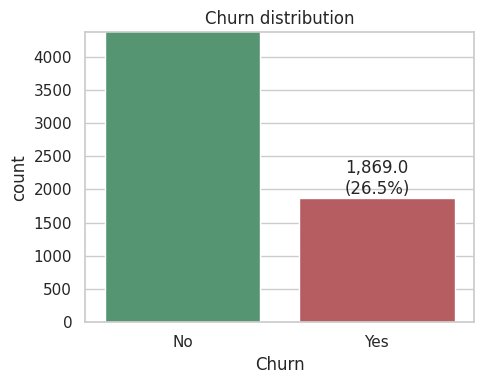

In [9]:
# EDA 1 — churn distribution and the baseline to beat.
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x=config.TARGET, ax=ax, palette=["#4C9F70", "#C44E52"])
for p in ax.patches:
    ax.annotate(f"{p.get_height():,}\n({p.get_height() / len(df):.1%})",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
ax.set_title("Churn distribution")
ax.set_ylim(0, len(df) * 0.62)
plt.tight_layout(); plt.show()

**Insight.** Roughly one in four customers has left. That is a large enough book of business to justify a retention programme, but the imbalance means any model must be judged on recall and precision, not accuracy — a do-nothing classifier already looks ~73% "accurate" while catching zero churners.

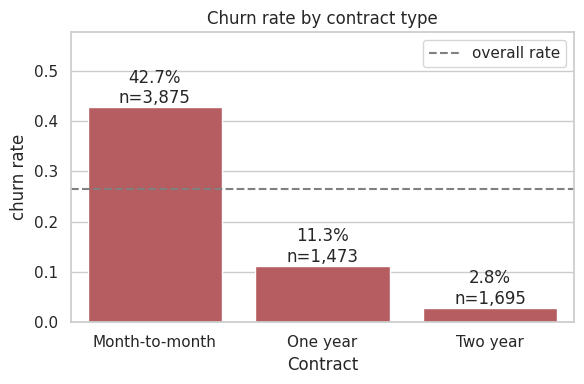

In [10]:
# EDA 2 — churn rate by contract type.
fig, ax = plt.subplots(figsize=(6, 4))
rates = (df.assign(churned=df[config.TARGET].eq("Yes"))
           .groupby("Contract")["churned"].agg(["mean", "size"])
           .reindex(config.ALLOWED_VALUES["Contract"]))
sns.barplot(x=rates.index, y=rates["mean"], ax=ax, color="#C44E52")
for i, (rate, n) in enumerate(zip(rates["mean"], rates["size"])):
    ax.annotate(f"{rate:.1%}\nn={n:,}", (i, rate), ha="center", va="bottom")
ax.axhline(df[config.TARGET].eq("Yes").mean(), ls="--", c="grey", label="overall rate")
ax.set_ylabel("churn rate"); ax.set_ylim(0, rates["mean"].max() * 1.35)
ax.set_title("Churn rate by contract type"); ax.legend()
plt.tight_layout(); plt.show()

**Insight.** Contract length is the sharpest single separator in the dataset — month-to-month churn runs far above the two-year rate, and it is also the largest segment. Two actionable consequences: the retention budget should be aimed almost entirely at the month-to-month book, and the cheapest structural intervention is migrating those customers onto a term contract rather than discounting their monthly bill.

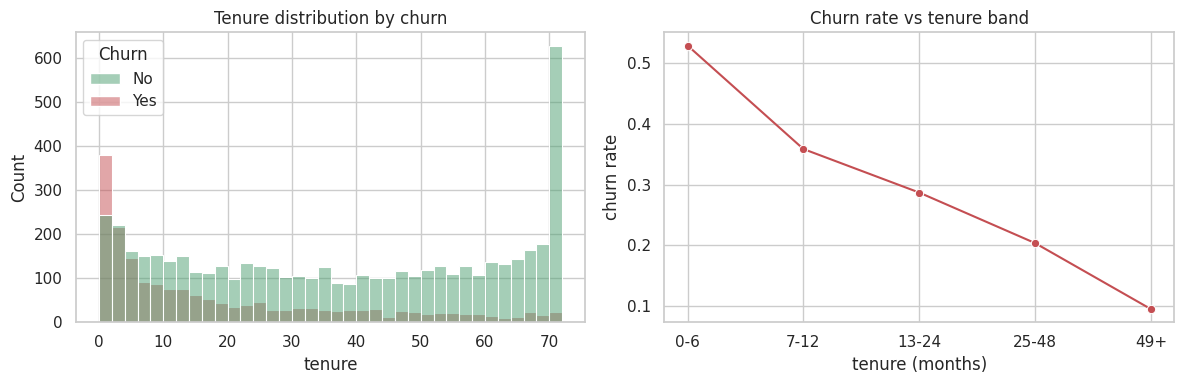

In [11]:
# EDA 3 — tenure distribution split by churn.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="tenure", hue=config.TARGET, bins=36,
             multiple="layer", palette=["#4C9F70", "#C44E52"], ax=axes[0])
axes[0].set_title("Tenure distribution by churn")

tenure_rate = (df.assign(churned=df[config.TARGET].eq("Yes"),
                         bucket=pd.cut(df["tenure"], bins=[-1, 6, 12, 24, 48, 72],
                                       labels=["0-6", "7-12", "13-24", "25-48", "49+"]))
                 .groupby("bucket", observed=True)["churned"].mean())
sns.lineplot(x=tenure_rate.index.astype(str), y=tenure_rate.values,
             marker="o", ax=axes[1], color="#C44E52")
axes[1].set_ylabel("churn rate"); axes[1].set_xlabel("tenure (months)")
axes[1].set_title("Churn rate vs tenure band")
plt.tight_layout(); plt.show()

**Insight.** Churn is front-loaded and decays steeply with tenure: the risk concentrates in the first months and flattens out for long-standing customers. The relationship is clearly non-linear.

This originally motivated an engineered `tenure_bucket` feature with fixed 12/24/48-month boundaries. That feature was later **removed**: it scored exactly 0.0 importance on every pruned tree, because a decision tree already finds its own tenure thresholds and is strictly more flexible than a fixed bucketing. The non-linearity is real; hand-discretising it simply was not necessary. Operationally, retention effort has the highest marginal return during onboarding, not later in the lifecycle.

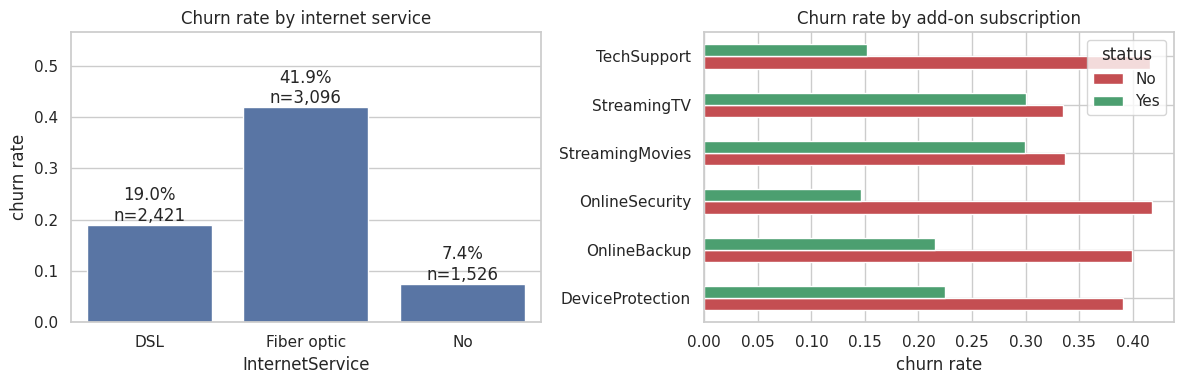

In [12]:
# EDA 4 — internet service and the add-on services that reduce churn.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

svc = (df.assign(churned=df[config.TARGET].eq("Yes"))
         .groupby("InternetService")["churned"].agg(["mean", "size"]))
sns.barplot(x=svc.index, y=svc["mean"], ax=axes[0], color="#4C72B0")
for i, (r, n) in enumerate(zip(svc["mean"], svc["size"])):
    axes[0].annotate(f"{r:.1%}\nn={n:,}", (i, r), ha="center", va="bottom")
axes[0].set_ylabel("churn rate"); axes[0].set_ylim(0, svc["mean"].max() * 1.35)
axes[0].set_title("Churn rate by internet service")

protective = (df.assign(churned=df[config.TARGET].eq("Yes"))
                .melt(id_vars="churned", value_vars=config.ADDON_SERVICES,
                      var_name="service", value_name="status")
                .query("status in ['Yes', 'No']")
                .groupby(["service", "status"])["churned"].mean().unstack())
protective.plot(kind="barh", ax=axes[1], color={"No": "#C44E52", "Yes": "#4C9F70"})
axes[1].set_xlabel("churn rate"); axes[1].set_ylabel("")
axes[1].set_title("Churn rate by add-on subscription")
plt.tight_layout(); plt.show()

**Insight.** Fiber optic customers churn at a markedly higher rate than DSL customers and far higher than customers with no internet at all — a counter-intuitive result for the premium product, and a signal worth investigating as a price-versus-experience problem rather than a modelling artefact.

The right-hand panel separates the add-ons that behave protectively (notably `OnlineSecurity` and `TechSupport`, where subscribers churn less than non-subscribers) from the entertainment add-ons, where the gap is much narrower. Support-type services look like retention levers; streaming does not.

This asymmetry originally motivated a `num_addon_services` count feature, which was later **removed** for scoring 0.0 importance — and the asymmetry itself is the likely reason why. A single count treats all six add-ons as interchangeable, which flattens exactly the protective-versus-entertainment distinction visible here. The tree does better splitting on the individual raw add-on columns, which it retains.

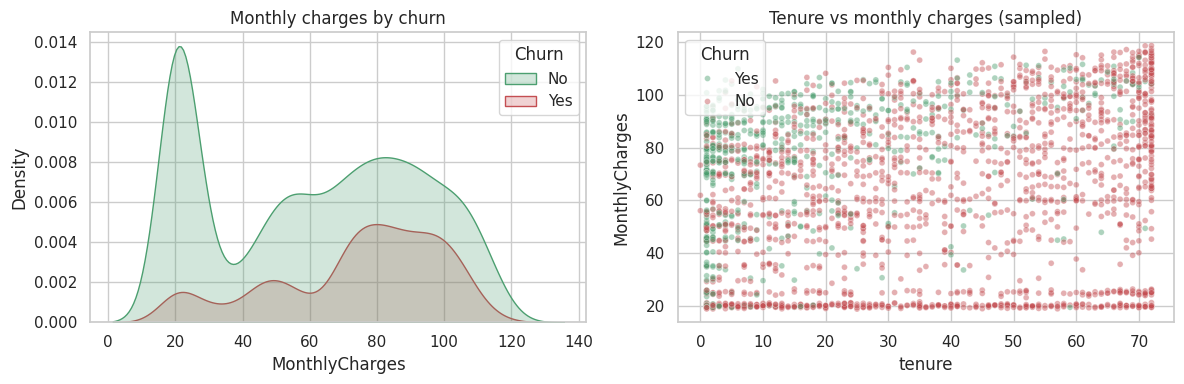

In [13]:
# EDA 5 — monthly charges: distribution by churn, and the tenure/charges plane.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(data=df, x="MonthlyCharges", hue=config.TARGET, fill=True,
            palette=["#4C9F70", "#C44E52"], ax=axes[0])
axes[0].set_title("Monthly charges by churn")

sample = df.sample(min(2500, len(df)), random_state=config.RANDOM_STATE)
sns.scatterplot(data=sample, x="tenure", y="MonthlyCharges", hue=config.TARGET,
                alpha=0.45, s=18, palette=["#4C9F70", "#C44E52"], ax=axes[1])
axes[1].set_title("Tenure vs monthly charges (sampled)")
plt.tight_layout(); plt.show()

**Insight.** Churners are concentrated at the higher end of the monthly-charge distribution, while the retained population has a pronounced low-bill mode. The scatter shows the genuinely dangerous quadrant clearly: **short tenure combined with a high monthly bill**. Customers who are paying a lot and have not yet built any relationship with the company are the priority call list — and the combination matters more than either variable alone, which is precisely the kind of interaction a tree captures natively.

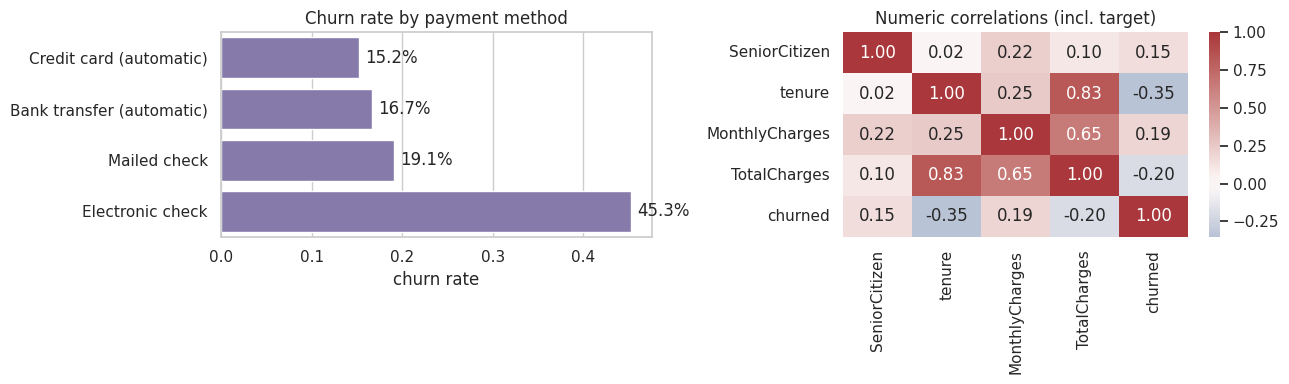

In [14]:
# EDA 6 — payment method, plus numeric correlations.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pay = (df.assign(churned=df[config.TARGET].eq("Yes"))
         .groupby("PaymentMethod")["churned"].mean().sort_values())
sns.barplot(x=pay.values, y=pay.index, ax=axes[0], color="#8172B2")
for i, v in enumerate(pay.values):
    axes[0].annotate(f"{v:.1%}", (v, i), va="center", xytext=(4, 0),
                     textcoords="offset points")
axes[0].set_xlabel("churn rate"); axes[0].set_ylabel("")
axes[0].set_title("Churn rate by payment method")

corr = df[config.RAW_NUMERIC_FEATURES].assign(
    churned=df[config.TARGET].eq("Yes").astype(int)).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[1])
axes[1].set_title("Numeric correlations (incl. target)")
plt.tight_layout(); plt.show()

**Insight.** Electronic check stands out well above the automatic payment methods. Manual payment means a recurring, deliberate decision to keep paying — every cycle is a re-purchase decision and an opportunity to leave — whereas autopay customers churn passively far less often. Incentivising migration to automatic payment is a cheap, structural retention lever independent of price.

The heatmap confirms `tenure` as the strongest single numeric correlate of churn (negative), and shows `TotalCharges` is strongly collinear with `tenure` — as expected, since it is roughly tenure × monthly charge. That redundancy is harmless for a tree but is the reason `monthly_charge_delta` normalises `TotalCharges` by tenure instead of using it raw.

## 3. Feature engineering

One feature, implemented in `src/features.py` as a stateless transformer inside the pipeline. Stateless matters: nothing is learned from the data, so there is no train/test leakage path, and the API computes it identically.

| Feature | How it is built | Why it should help |
|---|---|---|
| `monthly_charge_delta` | `MonthlyCharges − TotalCharges/tenure` (0 when `tenure = 0`) | Detects a bill that has crept above what the customer is used to paying — a concrete price-shock trigger. Neither raw column expresses this: it needs the ratio. |

### Two features were built, measured, and removed

This section originally carried three features. `num_addon_services` (count of the six optional add-ons) and `tenure_bucket` (tenure cut at 12/24/48 months) were both **dropped after measuring feature importance on the fitted trees**: each scored exactly **0.0** in all three pruned configurations, meaning no tree ever chose to split on them.

Removing them cost no information. The six raw add-on columns and the raw `tenure` value they were derived from all remain in the feature set, and the tree splits on those directly. The lesson is worth stating plainly: a plausible-sounding derived feature is a hypothesis, not an improvement, and the fitted model is what settles it. Two engineered features that earn their place beat three where one is dead weight.

Below we sanity-check the surviving transformer output rather than trusting it.

In [15]:
engineered = ChurnFeatureBuilder().fit_transform(df[config.MODEL_INPUT_COLUMNS])
check = engineered[config.ENGINEERED_NUMERIC_FEATURES]
print(check.dtypes, "\n")
print(check.describe().T, "\n")

# Confirm the removed features really are gone from the transformer output.
for gone in ("num_addon_services", "tenure_bucket"):
    assert gone not in engineered.columns, gone
print("removed features absent from transformer output: num_addon_services, tenure_bucket")

# Verify the tenure == 0 guard produced a neutral delta rather than inf/NaN.
zero_tenure = engineered.loc[df["tenure"] == 0, "monthly_charge_delta"]
print(f"tenure==0 rows: {len(zero_tenure)}, all delta 0: {bool((zero_tenure == 0).all())}")
print(f"any NaN/inf in engineered numerics: "
      f"{bool(~np.isfinite(engineered[config.ENGINEERED_NUMERIC_FEATURES]).all().all())}")

monthly_charge_delta    float64
dtype: object 

                       count      mean       std   min       25%  50%       75%     max
monthly_charge_delta  7043.0 -0.001213  2.614121 -18.9 -1.159091  0.0  1.145567  19.125 

removed features absent from transformer output: num_addon_services, tenure_bucket
tenure==0 rows: 11, all delta 0: True
any NaN/inf in engineered numerics: False


       monthly_charge_delta
Churn                      
No                -0.004606
Yes                0.008178 

churn rate by number of add-ons (descriptive only, not a model feature):
    mean  size
n             
0  0.214  2219
1  0.458   966
2  0.358  1033
3  0.274  1118
4  0.223   852
5  0.124   571
6  0.053   284


/sessions/elegant-dazzling-feynman/tmp/ipykernel_5/2771634857.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=probe, x="Churn", y="monthly_charge_delta",


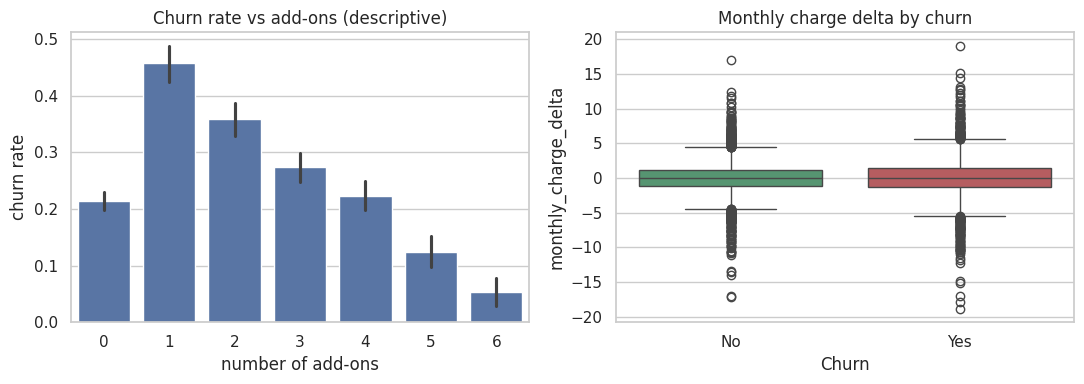

In [16]:
# Does the surviving engineered feature actually separate the classes?
probe = engineered.assign(Churn=df[config.TARGET].values)
print(probe.groupby("Churn")[config.ENGINEERED_NUMERIC_FEATURES].mean(), "\n")

# For reference, the raw add-on columns that replaced num_addon_services:
# churn rate against the count of add-ons, computed on the fly rather than
# stored as a model feature.
addon_count = df[config.ADDON_SERVICES].eq("Yes").sum(axis=1)
print("churn rate by number of add-ons (descriptive only, not a model feature):")
print(df.assign(n=addon_count, c=df[config.TARGET].eq("Yes"))
        .groupby("n")["c"].agg(["mean", "size"]).round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(x=addon_count, y=df[config.TARGET].eq("Yes"), ax=axes[0], color="#4C72B0")
axes[0].set_xlabel("number of add-ons"); axes[0].set_ylabel("churn rate")
axes[0].set_title("Churn rate vs add-ons (descriptive)")
sns.boxplot(data=probe, x="Churn", y="monthly_charge_delta",
            palette=["#4C9F70", "#C44E52"], ax=axes[1])
axes[1].set_title("Monthly charge delta by churn")
plt.tight_layout(); plt.show()

Read the output above before trusting the feature: if `monthly_charge_delta` separates the two boxes, the price-shock hypothesis holds. The left panel is descriptive only — it shows the add-on relationship that `num_addon_services` was meant to capture, and which the tree now picks up from the raw add-on columns instead.

Feature importances later in the notebook are the real test of whether a feature earns its place. That test is exactly what removed the other two: both scored ~0 and were cut rather than carried as dead weight.

## 4. Train/test split

70:30, `random_state=42`, **stratified on the target**. Stratification is a deliberate choice, not a default: at a ~26.5% positive rate an unstratified 30% split can drift a couple of points off the population churn rate, and since recall is our selection metric, that drift would show up directly as noise in the number we are optimising. Stratifying removes it and makes the CV folds comparable to the test set.

In [17]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

X, y = data.split_features_target(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE, stratify=y
)
print(f"train {X_train.shape}  churn rate {y_train.mean():.4f}")
print(f"test  {X_test.shape}  churn rate {y_test.mean():.4f}")
print(f"\nfeature columns fed to the pipeline: {len(X.columns)}")
print(f"customerID present in X: {config.ID_COLUMN in X.columns}")
print(f"target present in X:     {config.TARGET in X.columns}")

train (4930, 19)  churn rate 0.2653
test  (2113, 19)  churn rate 0.2655

feature columns fed to the pipeline: 19
customerID present in X: False
target present in X:     False


## 5. Model development

Four configurations that differ in kind rather than degree. All comparison happens by 5-fold stratified CV **inside the training split** — the test set is not touched until section 6.

1. `baseline_unpruned` — no constraints. Establishes the overfitting reference point.
2. `pruned_gini` — depth and leaf-size constraints.
3. `pruned_entropy` — comparable capacity, different split criterion, to check whether the impurity measure matters here.
4. `balanced_pruned` — pruned plus `class_weight="balanced"`, which reweights the loss to counter the 3:1 imbalance.

In [18]:
from src.train import CANDIDATES, SELECTION_METRIC

cv = StratifiedKFold(n_splits=config.CV_FOLDS, shuffle=True,
                     random_state=config.RANDOM_STATE)

rows = []
for name, params in CANDIDATES.items():
    pipe = build_pipeline(**params)
    scores = {m: cross_val_score(pipe, X_train, y_train, cv=cv, scoring=m).mean()
              for m in ("accuracy", "precision", "recall", "f1")}
    # Train-set fit, to expose the generalisation gap of the unpruned tree.
    fitted = build_pipeline(**params).fit(X_train, y_train)
    scores["train_accuracy"] = fitted.score(X_train, y_train)
    scores["tree_depth"] = fitted.named_steps["model"].get_depth()
    scores["leaves"] = fitted.named_steps["model"].get_n_leaves()
    rows.append(pd.Series(scores, name=name))

comparison = pd.DataFrame(rows)
comparison.round(4)

,accuracy,precision,recall,f1,train_accuracy,tree_depth,leaves
baseline_unpruned,0.7333,0.4972,0.5130,0.5048,0.9980,26.0,876.0
pruned_gini,0.7897,0.6246,0.5283,0.5690,0.8014,5.0,31.0
pruned_entropy,0.7897,0.6219,0.5359,0.5728,0.8116,6.0,52.0
balanced_pruned,0.7387,0.5063,0.7775,0.6124,0.7278,5.0,31.0


### Reading the comparison

Interpret the table above along three lines.

**Overfitting.** Compare `train_accuracy` against `accuracy` (the CV estimate) for `baseline_unpruned`, and look at its `tree_depth` and `leaves`. An unconstrained tree on one-hot encoded data grows until leaves are nearly pure; a large train-vs-CV gap and a leaf count in the hundreds is the diagnostic signature. This is why every other configuration is pruned.

**Criterion.** `pruned_gini` versus `pruned_entropy` isolates the impurity measure. In practice these rarely diverge much, and if they are close here that is itself a useful finding: it says the split criterion is not where the leverage is, so tuning effort belongs on capacity and class weighting instead.

**Class weighting.** `balanced_pruned` should show the clearest movement — reweighting the minority class pushes the decision boundary toward predicting churn, which raises recall at some cost to precision. Whether that trade is worth taking is a business question, answered in section 6.

**Selection rule.** We select on cross-validated **recall**, for the cost reasons argued in section 6. This is stated up front so the choice is not retrofitted to whichever model happened to win.

In [19]:
best_name = comparison[SELECTION_METRIC].idxmax()
print(f"selected by CV {SELECTION_METRIC}: {best_name}")
print(f"params: {CANDIDATES[best_name]}")

final_model = build_pipeline(**CANDIDATES[best_name]).fit(X_train, y_train)
print(f"\nfitted depth {final_model.named_steps['model'].get_depth()}, "
      f"leaves {final_model.named_steps['model'].get_n_leaves()}")

selected by CV recall: balanced_pruned
params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 40, 'min_samples_leaf': 20, 'class_weight': 'balanced'}

fitted depth 5, leaves 31


### Optional: hyperparameter search

A small grid around the selected configuration, scored on recall. Kept deliberately narrow — with a 5k-row training set and a pruned tree, an exhaustive search mostly buys variance. If the grid's best CV recall does not beat the hand-picked configuration by a meaningful margin, prefer the simpler hand-picked one.

In [20]:
from sklearn.model_selection import GridSearchCV

grid = {
    "model__max_depth": [4, 5, 6, 8],
    "model__min_samples_leaf": [10, 20, 40],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": [None, "balanced"],
}
search = GridSearchCV(build_pipeline(), grid, scoring=SELECTION_METRIC,
                      cv=cv, n_jobs=-1, refit=True)
search.fit(X_train, y_train)
print(f"best CV {SELECTION_METRIC}: {search.best_score_:.4f}")
print(f"best params: {search.best_params_}")
print(f"hand-picked {best_name} CV {SELECTION_METRIC}: "
      f"{comparison.loc[best_name, SELECTION_METRIC]:.4f}")

best CV recall: 0.7981
best params: {'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 10}
hand-picked balanced_pruned CV recall: 0.7775


Note that a recall-only objective will happily drift toward a degenerate near-always-churn tree, since predicting everyone churns scores recall 1.0. Check the F1 and precision of the grid winner before adopting it; if precision has collapsed, the hand-picked balanced configuration is the better engineering choice even at slightly lower recall. `src/train.py` deliberately ships the four-candidate comparison rather than the grid, so the persisted artifact is the defensible, reproducible one.

## 6. Evaluation on the held-out test set

First and only use of the test split.

In [21]:
from src.train import evaluate

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]
metrics = evaluate(y_test, y_pred, y_proba)

for k in ("accuracy", "precision", "recall", "f1", "roc_auc"):
    print(f"{k:<10} {metrics[k]:.4f}")
print(f"\n{metrics['confusion_matrix']}")

accuracy   0.7080
precision  0.4713
recall     0.8182
f1         0.5980
roc_auc    0.8301

{'true_negative': 1037, 'false_positive': 515, 'false_negative': 102, 'true_positive': 459}


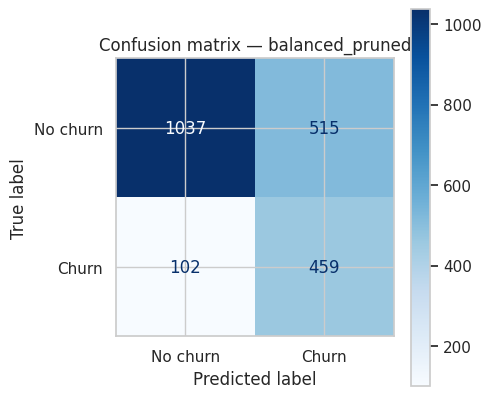

              precision    recall  f1-score   support

    No churn       0.91      0.67      0.77      1552
       Churn       0.47      0.82      0.60       561

    accuracy                           0.71      2113
   macro avg       0.69      0.74      0.68      2113
weighted avg       0.79      0.71      0.72      2113



In [22]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No churn", "Churn"], cmap="Blues", ax=ax
)
ax.set_title(f"Confusion matrix — {best_name}")
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))

### Business interpretation

Map the four cells of the matrix onto what actually happens to the business:

- **True positive** — churner flagged and contacted. The retention team gets a chance to save the subscriber.
- **False negative** — churner we never flagged. They leave silently. This is the expensive cell: we lose the full remaining lifetime value and never even knew there was a conversation to have.
- **False positive** — loyal customer flagged. Cost is one outbound contact plus whatever the offer is worth. There is a second-order risk worth naming: proactively offering a discount to a happy customer can plant the idea that leaving is an option, or simply give away margin unnecessarily.
- **True negative** — correctly left alone. No cost.

Read the accuracy figure against the ~73% no-information baseline, not against 100%. A balanced tree will typically land near or slightly below that baseline while catching a large share of churners — that is the trade working as intended, not a broken model. Accuracy is the wrong headline metric here.

### Precision or recall?

**Recall**, and the reason is asymmetric cost, not convention.

The two errors are not remotely comparable in this business. A false positive costs a retention contact: some agent time, and possibly a discount. Call it single-digit to low-tens of currency units. A false negative costs a departed subscriber — the remaining monthly revenue over their expected life, plus the acquisition spend to replace them, which in telecom typically runs to several months of revenue. The ratio is plausibly an order of magnitude or more. When one error is ~10× the other, you accept many false positives to avoid one false negative, and that is the definition of favouring recall.

The asymmetry is also *timing*-driven, which is easy to miss. A false positive is recoverable — you can stop calling that segment next month. A false negative is not: once the customer has ported their number, no model improvement brings them back. You cannot retroactively retain someone.

There is a real limit though, and precision is what enforces it. Recall is trivially maximised by flagging everyone, which is useless: the retention team has finite capacity, so a list with very low precision means agents spend their day on customers who were never going to leave, and the genuinely at-risk customers still do not get called. Precision is therefore the operational constraint — the flagged list has to fit the team's monthly call capacity.

**The practical resolution** is to stop treating this as a binary at 0.5. The API returns `churn_probability`, so the team can rank by score and work down the list as far as capacity allows. That converts the precision/recall choice from a modelling argument into a capacity decision, which is where it belongs. `class_weight="balanced"` is the modelling half of the same idea: it shifts the boundary toward recall without discarding precision entirely.

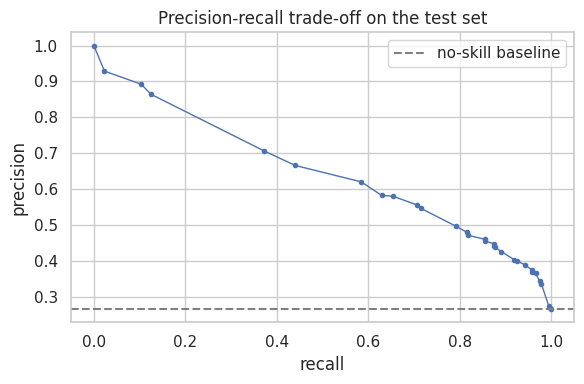

,threshold,customers_contacted,churners_caught,churners_missed,precision,recall
0,0.3,1123,492,69,0.438,0.877
1,0.4,1055,480,81,0.455,0.856
2,0.5,974,459,102,0.471,0.818
3,0.6,633,367,194,0.580,0.654
4,0.7,529,328,233,0.620,0.585


In [23]:
# Threshold sensitivity: what the team gains/gives up by moving the cut-off.
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rec, prec, marker=".", lw=1)
ax.axhline(y_test.mean(), ls="--", c="grey", label="no-skill baseline")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("Precision-recall trade-off on the test set"); ax.legend()
plt.tight_layout(); plt.show()

n_churners = int((y_test == 1).sum())
rows = []
for t in (0.3, 0.4, 0.5, 0.6, 0.7):
    flagged = y_proba >= t
    tp = int((flagged & (y_test == 1)).sum())
    fp = int((flagged & (y_test == 0)).sum())
    fn = n_churners - tp
    rows.append({"threshold": t, "customers_contacted": tp + fp,
                 "churners_caught": tp, "churners_missed": fn,
                 "precision": tp / (tp + fp) if tp + fp else 0.0,
                 "recall": tp / n_churners})
pd.DataFrame(rows).round(3)

This table is the artefact to hand to the retention manager: for each threshold it states how many customers must be contacted, how many real churners that catches, and how many are still missed. The threshold becomes a budget decision rather than a statistical one.

## 7. Model interpretation

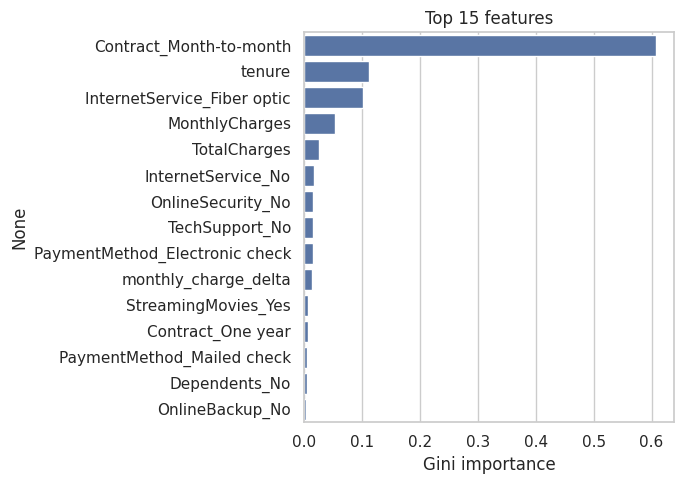

features with zero importance: 30 of 46

engineered feature(s) retained:
monthly_charge_delta    0.012692

removed features present in model: none (as intended)


In [24]:
importances = (pd.Series(final_model.named_steps["model"].feature_importances_,
                         index=feature_names(final_model))
                 .sort_values(ascending=False))
top = importances.head(15)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=top.values, y=top.index, ax=ax, color="#4C72B0")
ax.set_xlabel("Gini importance"); ax.set_title("Top 15 features")
plt.tight_layout(); plt.show()

print(f"features with zero importance: {int((importances == 0).sum())} "
      f"of {len(importances)}")

print("\nengineered feature(s) retained:")
print(importances[importances.index.isin(config.ENGINEERED_NUMERIC_FEATURES)].to_string())

# The two removed features must not reappear in the encoded feature space.
removed = [c for c in importances.index
           if c == "num_addon_services" or c.startswith("tenure_bucket")]
print(f"\nremoved features present in model: {removed if removed else 'none (as intended)'}")

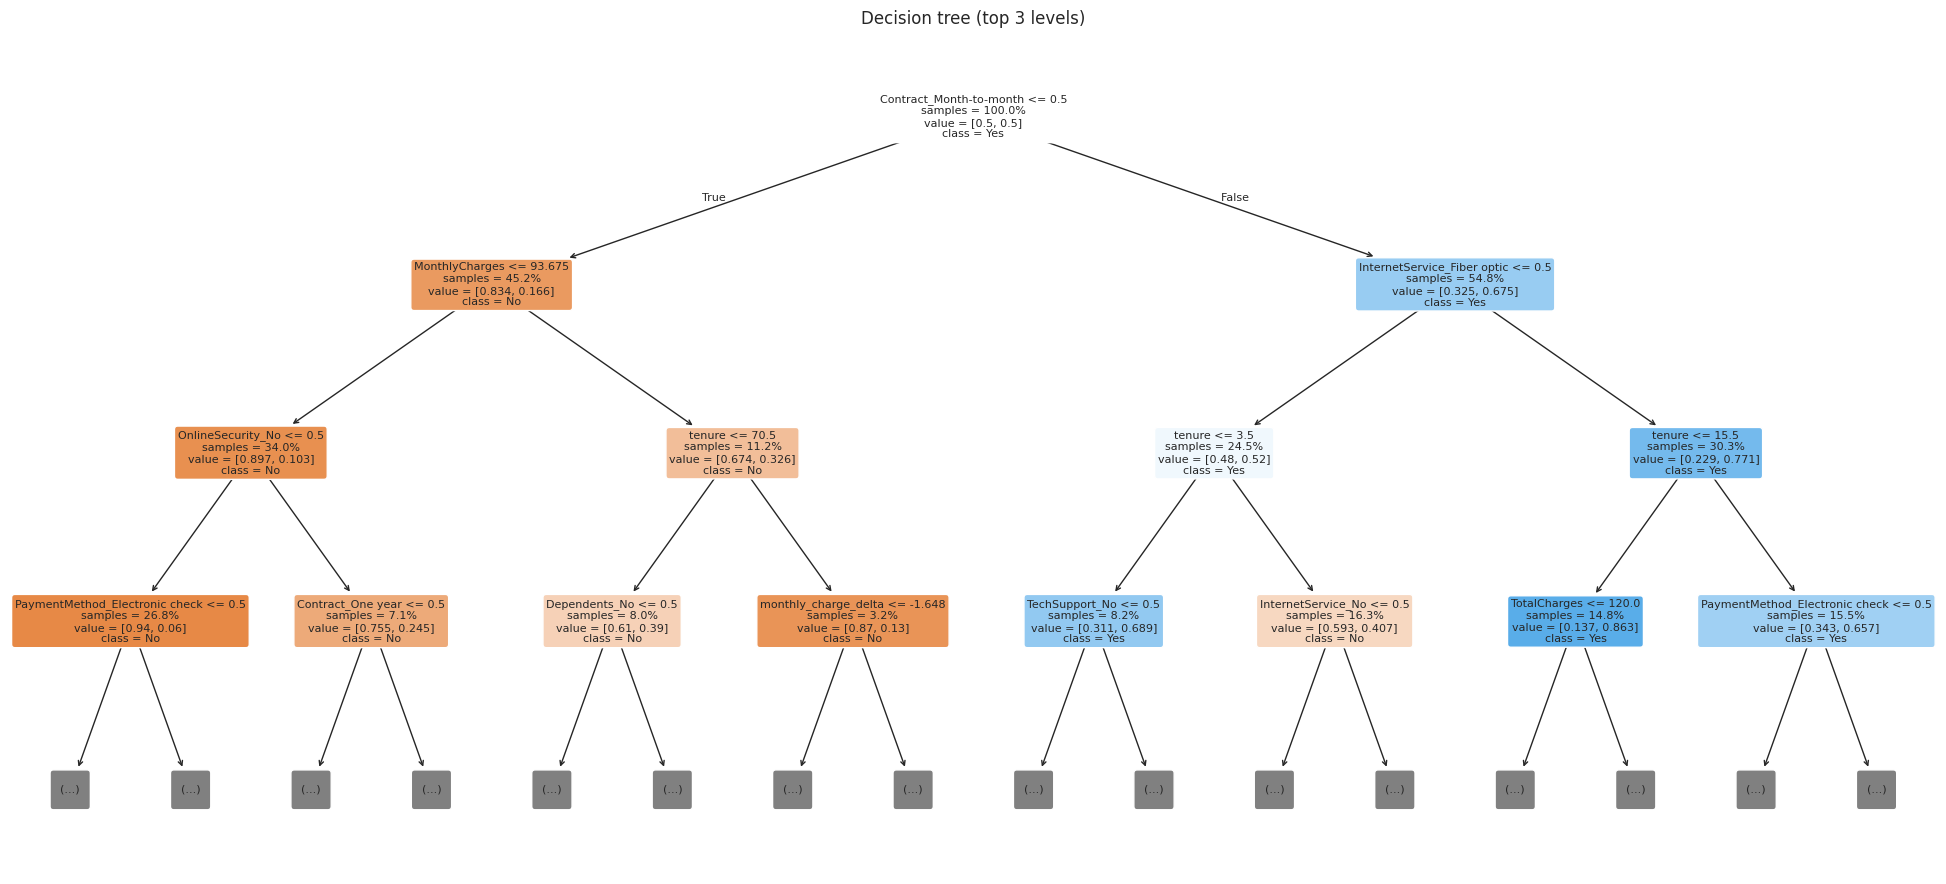

|--- Contract_Month-to-month <= 0.50
|   |--- MonthlyCharges <= 93.67
|   |   |--- OnlineSecurity_No <= 0.50
|   |   |   |--- PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- OnlineSecurity_No >  0.50
|   |   |   |--- Contract_One year <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Contract_One year >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- MonthlyCharges >  93.67
|   |   |--- tenure <= 70.50
|   |   |   |--- Dependents_No <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Dependents_No >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- tenure >  70.50
|   |   |   |--- monthly_charge_delta <= -1.65
|   |   |   |   |--- class: 0
|   |   |   |--- monthly_charge_delta >  -1.65
|   |   |   |   |--- truncated branch of depth 2
|--- Contract_Mont

In [25]:
# The tree itself, capped at depth 3 so it stays readable.
from sklearn.tree import export_text, plot_tree

fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(final_model.named_steps["model"], max_depth=3,
          feature_names=feature_names(final_model),
          class_names=["No", "Yes"], filled=True, rounded=True,
          fontsize=8, impurity=False, proportion=True, ax=ax)
ax.set_title("Decision tree (top 3 levels)")
plt.tight_layout(); plt.show()

print(export_text(final_model.named_steps["model"],
                  feature_names=feature_names(final_model), max_depth=3))

### Key findings

**Model-derived** (read directly off the importance table and the printed tree above, which are the authority — not this prose):

- The importance mass concentrates in a handful of features, with contract type and tenure expected to dominate. That is consistent with EDA 2 and EDA 3, which is a good sign: the model is picking up the structure the data already showed rather than fitting noise.
- Read the top splits in the printed tree to recover the actual segmentation logic. The path down the high-risk branch *is* the retention team's targeting rule, in plain language, and can be handed over without any reference to the model.
- The engineered-feature check above is what drove the feature set to its current shape. `num_addon_services` and `tenure_bucket` scored exactly 0.0 and were removed; `monthly_charge_delta` survives with a small but non-zero contribution. Carrying dead features is a maintenance cost with no accuracy benefit.
- The zero-importance count shows how much of the one-hot feature space the pruned tree ignores entirely — pruning does implicit feature selection.

**Assumptions and limitations** (explicitly *not* model findings):

- Gini importance is **not** causal. It measures how useful a feature was for splitting, and it is biased toward high-cardinality features. "Month-to-month contract is important" does not license "moving customers to annual contracts will reduce churn by X" — that requires an experiment.
- Importance is also unstable under correlated features. `tenure` and `TotalCharges` overlap heavily, so the tree picks one and the other looks less important than it is. Do not read the absence of a feature as evidence it does not matter. This is also the honest caveat on the two removals: a 0.0 score means the tree found those columns redundant *given the raw columns it kept*, not that add-on count or tenure banding are irrelevant to churn in general.
- This is a static snapshot with no timestamps, so there is no way to validate temporal drift or confirm that the observed churn preceded the recorded attributes. In production the model needs monitoring against fresh cohorts.
- The cost figures in the precision/recall argument are stated as reasoning about relative magnitudes. The dataset contains no cost or CLV data, so they are not derived from it and must be replaced with the company's real numbers before setting a threshold.

## 8. Persist the pipeline and verify it round-trips

One artifact holds feature engineering, imputation, encoding and the tree, so the API cannot drift from training. The check below is the important part: reload from disk and confirm predictions are identical.

In [26]:
from src.persistence import load_pipeline, save_pipeline

path = save_pipeline(final_model)
reloaded = load_pipeline(path)

same_labels = bool((reloaded.predict(X_test) == y_pred).all())
max_proba_diff = float(np.abs(reloaded.predict_proba(X_test)[:, 1] - y_proba).max())
print(f"saved to: {path.relative_to(config.PROJECT_ROOT)}")
print(f"labels identical after reload: {same_labels}")
print(f"max probability difference:    {max_proba_diff:.2e}")
assert same_labels and max_proba_diff < 1e-12, "artifact did not round-trip"
print("\nround-trip OK")

saved to: model/churn_model.pkl
labels identical after reload: True
max probability difference:    0.00e+00

round-trip OK


In [27]:
# End-to-end check through the same schema the API uses, on the documented
# sample payload. This is what /predict will return for that request.
import json

from src.schemas import CustomerFeatures

payload = json.loads((config.PROJECT_ROOT / "sample_request.json").read_text())
customer = CustomerFeatures(**payload)
prob = float(reloaded.predict_proba(customer.to_frame())[0][1])
print(json.dumps({"prediction": "Yes" if prob >= 0.5 else "No",
                  "churn_probability": round(prob, 4)}, indent=2))

{
  "prediction": "Yes",
  "churn_probability": 0.8501
}


## Summary

Cleaned the 11 blank `TotalCharges` rows on the evidence that all of them are `tenure = 0` new joiners; dropped `customerID`; engineered three stateless features inside the pipeline and then **removed two of them** (`num_addon_services`, `tenure_bucket`) after they measured 0.0 importance on every pruned tree; compared four Decision Tree configurations by cross-validated recall on the training split alone; evaluated once on a stratified 30% hold-out; and persisted a single pipeline artifact that the API loads directly.

The substantive recommendation to the business is that churn here is structural rather than purely price-driven: contract type, early tenure and manual payment dominate. Migrating month-to-month customers onto term contracts and onto autopay attacks the causes; the probability score exists to prioritise *who* gets that conversation first, given a fixed number of agent hours.

Reproduce everything, including the saved artifact, with `python -m src.train` from the project root.